1: 
  Los valores del flujo para los tiempos [10 11 12 13 14] (en minutos) son 
  [ 87.00961894  89.5        100.         110.5        112.99038106] respectivamente, los cuales se muestan en la siguiente gráfica:


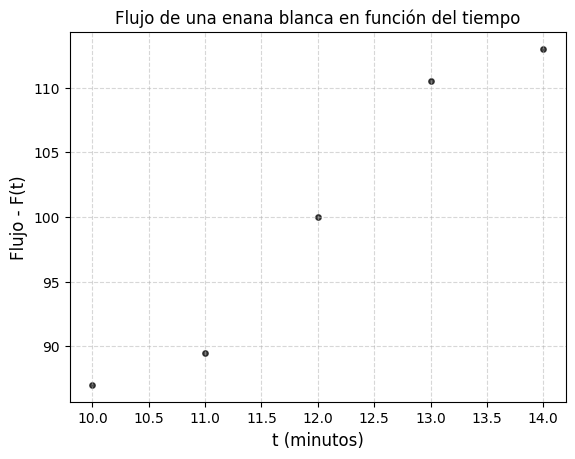

In [2]:
import numpy as np
import matplotlib.pyplot as plt

minutos = np.linspace(10, 14, 5)
dt = 1
t0 = 12

def Flux(t):
    return 100 + 15*np.sin(np.pi * t / 6) + 3*np.sin(np.pi * t / 2)

# 1. Evaluando F(t) en los minutos especificados:

flux_min = Flux(minutos)

print(f"1: \n  Los valores del flujo para los tiempos {minutos.astype(int)} (en minutos) son \n  {flux_min} respectivamente, los cuales se muestan en la siguiente gráfica:")

plt.figure()
plt.scatter(minutos, flux_min, color='k', s=15, alpha=0.7)
plt.xlabel("t (minutos)", fontsize=12)
plt.ylabel("Flujo - F(t)", fontsize=12)
plt.grid(linestyle='--', alpha=0.5)
plt.title("Flujo de una enana blanca en función del tiempo")
plt.show()

In [3]:
# 2. Para las derivadas por diferencias finitas:

def diff_forward(f, x, h):                    # Derivada - Método hacia adelante
    return (f(x + h) - f(x)) / h

def diff_backward(f, x, h):                   # Derivada - Método hacia atrás
    return (f(x) - f(x - h)) / h

def diff_centered(f, x, h):                   # Derivada - Método centrado
    return (f(x + h) - f(x - h)) / (2*h)

# Analíticamente:

def F_dot(t):
    return (np.pi * 15 / 6)*np.cos(np.pi * t / 6) + (np.pi * 3 / 2)*np.cos(np.pi * t / 2)

der_f =  diff_forward(Flux, t0, dt)
der_b = diff_backward(Flux, t0, dt)
der_c = diff_centered(Flux, t0, dt)

print("\n2:")
print(f"  La derivada del flujo evaluada en t0 = {t0} min, calculada con diferencias finitas hacia adelante es: {der_f}")
print(f"  La derivada del flujo evaluada en t0 = {t0} min, calculada con diferencias finitas hacia atrás es: {der_b}")
print(f"  La derivada del flujo evaluada en t0 = {t0} min, calculada con diferencias finitas centrada es: {der_c}")

# 3. Calculando el valor verdadero y los errores relativos porcentuales

der_real = F_dot(t0)

eps_derf = np.abs( (der_f - der_real) / der_real ) * 100
eps_derb = np.abs( (der_b - der_real) / der_real ) * 100
eps_derc = np.abs( (der_c - der_real) / der_real ) * 100

print("\n3:")
print(f"> El valor verdadero (analítico) de la derivada del flujo en t0 = {t0} es: {der_real}.")
print(f"  El error relativo porcentual para el método hacia adelante es eps_der_f = {eps_derf} %.")
print(f"  El error relativo porcentual para el método hacia atrás es eps_der_b = {eps_derb} %.")
print(f"  El error relativo porcentual para el método centrado es eps_der_c = {eps_derc} %.")


2:
  La derivada del flujo evaluada en t0 = 12 min, calculada con diferencias finitas hacia adelante es: 10.5
  La derivada del flujo evaluada en t0 = 12 min, calculada con diferencias finitas hacia atrás es: 10.5
  La derivada del flujo evaluada en t0 = 12 min, calculada con diferencias finitas centrada es: 10.5

3:
> El valor verdadero (analítico) de la derivada del flujo en t0 = 12 es: 12.566370614359172.
  El error relativo porcentual para el método hacia adelante es eps_der_f = 16.443654876754945 %.
  El error relativo porcentual para el método hacia atrás es eps_der_b = 16.443654876754945 %.
  El error relativo porcentual para el método centrado es eps_der_c = 16.443654876754945 %.
